
File: tumor.root
Entries: 100000
Used detector gammas: 2147
Image max: 8.0
Nonzero pixels: 4884

File: phantom.root
Entries: 100000
Used detector gammas: 4291
Image max: 12.0
Nonzero pixels: 4775


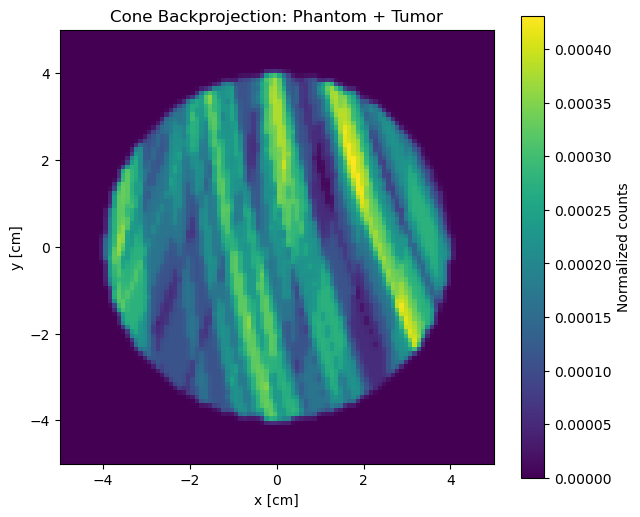

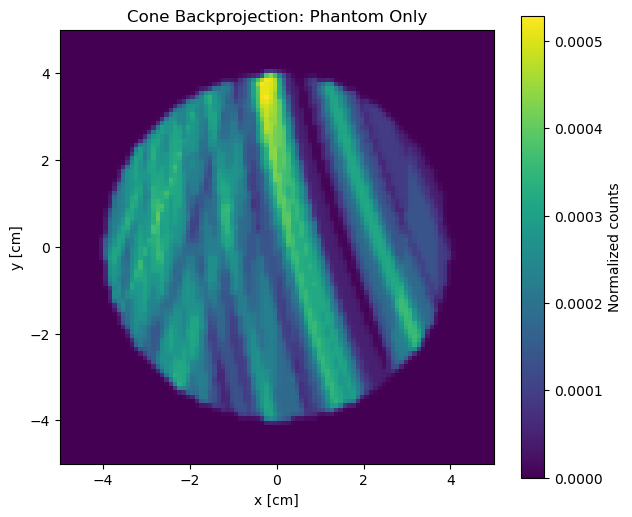

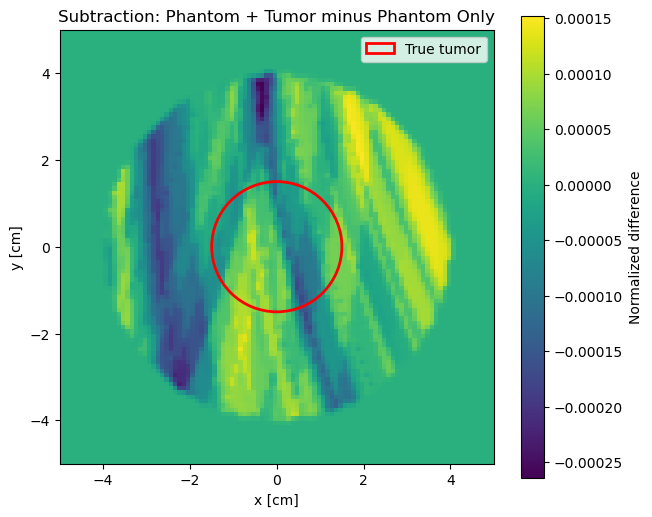

In [1]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# =========================
# USER SETTINGS
# =========================
tumor_file = "tumor.root"
phantom_file = "phantom.root"
tree_name = "t"

detector_vlms = [4, 5, 6]

E0 = 662.0
me = 511.0

source_pos = np.array([0.0, 20.0, 0.0])

xmin, xmax = -5.0, 5.0
ymin, ymax = -5.0, 5.0
z_slice = 0.0
phantom_radius = 4.0

nx, ny = 100, 100
angle_tolerance = 0.02
max_detector_gammas = None

xs = np.linspace(xmin, xmax, nx)
ys = np.linspace(ymin, ymax, ny)

# =========================
# CONE BACKPROJECTION FUNCTION
# =========================
def cone_backproject(root_file):

    f = ROOT.TFile.Open(root_file)
    if not f or f.IsZombie():
        raise RuntimeError(f"Could not open ROOT file: {root_file}")

    t = f.Get(tree_name)
    if not t:
        raise RuntimeError(f"Could not find tree {tree_name} in {root_file}")

    image = np.zeros((ny, nx))
    used_detector_gammas = 0

    print("\nFile:", root_file)
    print("Entries:", t.GetEntries())

    for entry in t:
        n = min(
            len(entry.pdg),
            len(entry.vlm),
            len(entry.x),
            len(entry.y),
            len(entry.z),
            len(entry.et)
        )

        for i in range(n):
            if max_detector_gammas is not None and used_detector_gammas >= max_detector_gammas:
                   # if used_detector_gammas >= max_detector_gammas:
                break

        
           # only detector-recorded gammas
            if int(entry.pdg[i]) != 22:
                continue

            if int(entry.vlm[i]) not in detector_vlms:
                continue

            Es = float(entry.et[i])

            if Es <= 0 or Es >= E0:
                continue

            # Compton angle from detected scattered gamma energy
            cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

            if cos_theta < -1.0 or cos_theta > 1.0:
                continue

            theta = math.acos(cos_theta)

            detector_pos = np.array([
                float(entry.x[i]),
                float(entry.y[i]),
                float(entry.z[i])
            ])

            # backproject possible origins
            for iy, y in enumerate(ys):
                for ix, x in enumerate(xs):

                    # restrict to cylindrical phantom cross-section
                    if x*x + y*y > phantom_radius*phantom_radius:
                        continue

                    voxel = np.array([x, y, z_slice])

                    u_in = voxel - source_pos
                    u_out = detector_pos - voxel

                    norm_in = np.linalg.norm(u_in)
                    norm_out = np.linalg.norm(u_out)

                    if norm_in == 0 or norm_out == 0:
                        continue

                    u_in = u_in / norm_in
                    u_out = u_out / norm_out

                    alpha = math.acos(
                        np.clip(np.dot(u_in, u_out), -1.0, 1.0)
                    )

                    if abs(alpha - theta) < angle_tolerance:
                        image[iy, ix] += 1.0

            used_detector_gammas += 1

            if max_detector_gammas is not None and used_detector_gammas >= max_detector_gammas:
       # if used_detector_gammas >= max_detector_gammas:
              break

    print("Used detector gammas:", used_detector_gammas)
    print("Image max:", image.max())
    print("Nonzero pixels:", np.count_nonzero(image))

    f.Close()
    return image

# =========================
# RUN BOTH FILES
# =========================
image_tumor = cone_backproject(tumor_file)
image_phantom = cone_backproject(phantom_file)

# Normalize before subtraction
image_tumor_norm = image_tumor / (image_tumor.sum() + 1e-9)
image_phantom_norm = image_phantom / (image_phantom.sum() + 1e-9)

contrast = image_tumor_norm - image_phantom_norm
contrast_norm = contrast / (image_phantom_norm + 1e-9)

# Smooth
sigma = 0.6
image_tumor_s = gaussian_filter(image_tumor_norm, sigma=sigma)
image_phantom_s = gaussian_filter(image_phantom_norm, sigma=sigma)
contrast_s = gaussian_filter(contrast, sigma=sigma)

# =========================
# PLOT
# =========================

def plot_image(img, title, label, cmap_vmin=None, add_circle=False):

    plt.figure(figsize=(7, 6))

    plt.imshow(
        img,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        aspect="equal",
        vmin=cmap_vmin
    )

    plt.colorbar(label=label)

    plt.xlabel("x [cm]")
    plt.ylabel("y [cm]")

    plt.title(title)

    # =========================
    # OPTIONAL TRUE TUMOR CIRCLE
    # =========================
    if add_circle:

        from matplotlib.patches import Circle

        ax = plt.gca()

        ax.add_patch(
            Circle(
                (0, 0),      # tumor center
                1.5,         # radius = 1.5 cm
                fill=False,
                color="red",
                linewidth=2,
                label="True tumor"
            )
        )

        ax.legend()

    plt.show()
    
    
plot_image(
    image_tumor_s,
    "Cone Backprojection: Phantom + Tumor",
    "Normalized counts",
    0
)

plot_image(
    image_phantom_s,
    "Cone Backprojection: Phantom Only",
    "Normalized counts",
    0
)

plot_image(
    contrast_s,
    "Subtraction: Phantom + Tumor minus Phantom Only",
    "Normalized difference",
    None,
    add_circle=True
)